Step 1 & 2 - Project Setup and Data Loading
Description: This section initializes the project environment. We load the dataset into a Pandas DataFrame. The objective of this project is to predict "Profile Popularity." Instead of predicting the exact number of likes (regression), we will examine the distribution of likes_received to prepare for a classification approach.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Hides convergence warnings for cleaner output


# 2. Load the dataset from My Drive
# If you put the file inside a specific folder, add it to the path (e.g., '/content/drive/My Drive/Assignment/dating_app...')
file_path = "C:/Users/User/Documents/UM/Y1S2/WIA1006/GroupAssignment/dating_app_behavior_dataset_extended1.csv"
df = pd.read_csv(file_path)

# Display the initial dataset shape and the distribution of likes
print(f"Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nOriginal 'Likes Received' Statistics:")
print(df['likes_received'].describe())

Initial Dataset Shape: 50000 rows, 25 columns

Original 'Likes Received' Statistics:
count    50000.000000
mean        99.526040
std         57.996799
min          0.000000
25%         49.000000
50%        100.000000
75%        150.000000
max        200.000000
Name: likes_received, dtype: float64


Step 3 - Target Definition & Handling Data Leakage
Description: Here, we define our target variable. We convert the continuous likes_received column into three categories ('Low', 'Average', 'High') using quartiles. Then, we drop columns that would cause "data leakage." Data leakage happens when you train a model with information it wouldn't have in the real world at prediction time (e.g., you cannot know a match_outcome before a like is even sent).

In [10]:
# Create the target variable: 'popularity_class'
df['popularity_class'] = pd.qcut(df['likes_received'], q=3, labels=['Low', 'Average', 'High'])

print("Classification Target Distribution:")
print(df['popularity_class'].value_counts())

# Drop unnecessary or 'leaky' columns
# - 'likes_received': We are predicting the class now, not the number.
# - 'match_outcome': Happens after likes are received, causes data leakage.
columns_to_drop = ['likes_received', 'match_outcome']
df_cleaned = df.drop(columns=columns_to_drop)

print(f"\nRemaining columns after dropping leaks: {df_cleaned.columns.tolist()}")

Classification Target Distribution:
popularity_class
Low        16785
Average    16756
High       16459
Name: count, dtype: int64

Remaining columns after dropping leaks: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'age', 'height_cm', 'weight_kg', 'zodiac_sign', 'body_type', 'relationship_intent', 'popularity_class']


Step 4 - Feature Extraction and Encoding
Description: Machine learning models require numerical input. First, we extract a new feature (num_interests) by counting the items in the text-based interest_tags column, and then we drop the original text column. Finally, we use One-Hot Encoding to convert all categorical variables (like gender, location_type, zodiac_sign) into binary (1s and 0s) format.

In [ ]:
# 1. Feature Extraction: Count the number of interests
df_cleaned['num_interests'] = df_cleaned['interest_tags'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)

# Drop the original text 
df_cleaned = df_cleaned.drop(columns=['interest_tags', 'mutual_matches']) # mutual_match will cause data cheating as it is too dependent

# 2. Identify categorical columns that need to be converted to numbers
categorical_cols = ['gender', 'sexual_orientation', 'location_type', 'income_bracket',
                    'education_level', 'app_usage_time_label', 'swipe_right_label',
                    'swipe_time_of_day', 'zodiac_sign', 'body_type', 'relationship_intent']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Separate the Features (X) from the Target (y)
X = df_encoded.drop(columns=['popularity_class'])
y = df_encoded['popularity_class']

print(f"Final dataset shape for modeling: {X.shape[0]} rows and {X.shape[1]} features.")

Final dataset shape for modeling: 50000 rows and 77 features.


Step 5 - Train-Test Split & Evaluation Setup
Description: We split our dataset into a training set (80%) to teach the models, and a testing set (20%) to evaluate them on unseen data. We also define a single, reusable function evaluate_model to generate accuracy scores, classification reports, and confusion matrices for all our models, ensuring consistent evaluation.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a central evaluation function
def evaluate_model(model, model_name):
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)

    print(f"\n========================================")
    print(f"--- {model_name} Performance ---")
    print(f"========================================")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, predictions, labels=['Low', 'Average', 'High'])
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Average', 'High'],
                yticklabels=['Low', 'Average', 'High'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

    return acc

# Dictionary to keep track of all model scores
model_scores = {}
print("Data split successfully. Ready for modeling.")

Data split successfully. Ready for modeling.


Step 6 - Baseline Models (Model 1, 2, 3, 4)
Description: We train four baseline classification models strictly based on the syllabus: Logistic Regression (Week 3), Support Vector Machine (Week 9), Naive Bayes (Week 6), and a Neural Network (Week 5).

Training Logistic Regression...

--- Logistic Regression Performance ---
Accuracy: 0.3431

Classification Report:
              precision    recall  f1-score   support

     Average       0.35      0.37      0.36      3369
        High       0.33      0.29      0.31      3302
         Low       0.34      0.37      0.36      3329

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.34      0.34     10000



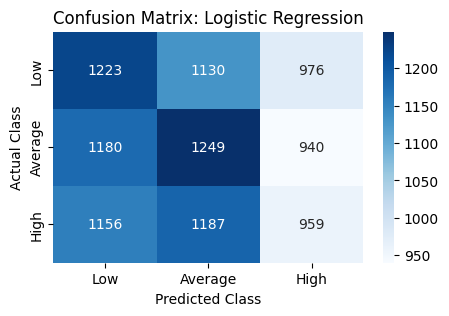

Training Support Vector Machine...

--- Support Vector Machine Performance ---
Accuracy: 0.3382

Classification Report:
              precision    recall  f1-score   support

     Average       0.34      0.42      0.38      3369
        High       0.36      0.06      0.10      3302
         Low       0.34      0.53      0.41      3329

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.30     10000
weighted avg       0.34      0.34      0.30     10000



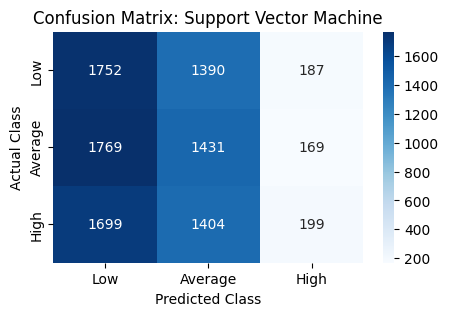

Training Naive Bayes...

--- Naive Bayes Performance ---
Accuracy: 0.3384

Classification Report:
              precision    recall  f1-score   support

     Average       0.34      0.35      0.35      3369
        High       0.33      0.34      0.33      3302
         Low       0.34      0.33      0.34      3329

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.34      0.34     10000



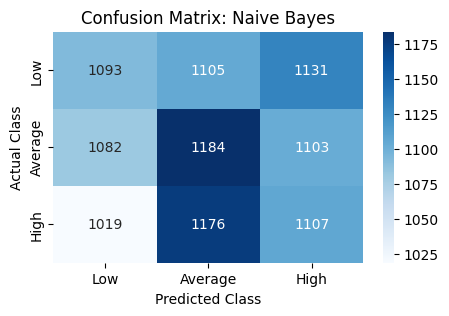

Training Neural Network (MLP)...

--- Neural Network Performance ---
Accuracy: 0.3300

Classification Report:
              precision    recall  f1-score   support

     Average       0.33      0.30      0.32      3369
        High       0.32      0.36      0.34      3302
         Low       0.33      0.32      0.33      3329

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000



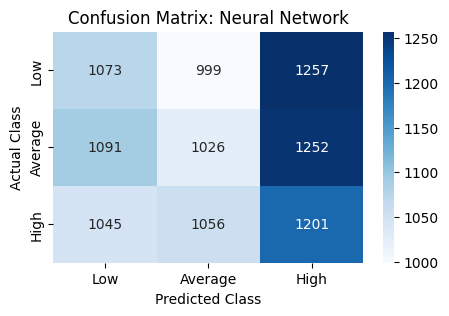

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. Logistic Regression (Week 3)
print("Training Logistic Regression...")
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
model_scores['Logistic Regression'] = evaluate_model(log_model, "Logistic Regression")

# 2. Support Vector Machine - SVM (Week 9)
print("Training Support Vector Machine...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
model_scores['SVM'] = evaluate_model(svm_model, "Support Vector Machine")

# 3. Naive Bayes (Week 6)
print("Training Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
model_scores['Naive Bayes'] = evaluate_model(nb_model, "Naive Bayes")

# 4. Neural Network (Week 5)
print("Training Neural Network (MLP)...")
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
model_scores['Neural Network'] = evaluate_model(nn_model, "Neural Network")

Step 6 - Model 5 & Hyperparameter Tuning (Random Forest)
Description: For our 5th model, we will use a Decision Tree (Week 4). To fulfill the "Hyperparameter tuning" requirement from the rubric, we will use GridSearchCV to test dozens of depth and splitting rules to find the absolute best version of the Decision Tree to prevent it from overfitting.

Starting Grid Search for Decision Tree (This tests multiple variations)...
Best Parameters Found: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}

--- Optimized Decision Tree Performance ---
Accuracy: 0.3337

Classification Report:
              precision    recall  f1-score   support

     Average       0.35      0.32      0.33      3369
        High       0.33      0.36      0.34      3302
         Low       0.33      0.32      0.33      3329

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.33      0.33      0.33     10000



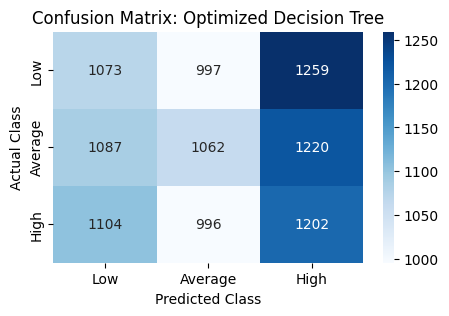

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the "grid" of settings we want to test for the Decision Tree
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],         # How deep the tree can grow
    'min_samples_split': [2, 10, 20],           # Minimum samples required to split a node
    'min_samples_leaf': [1, 5, 10],             # Minimum samples required at a leaf node
    'criterion': ['gini', 'entropy']            # How it measures the quality of a split
}

print("Starting Grid Search for Decision Tree (This tests multiple variations)...")

# Setup the Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy')

# Run the tuning process
grid_search.fit(X_train, y_train)

# Extract and evaluate the best model
print(f"Best Parameters Found: {grid_search.best_params_}")
best_dt = grid_search.best_estimator_
model_scores['Optimized Decision Tree'] = evaluate_model(best_dt, "Optimized Decision Tree")

Insights and Interpretation (Feature Importance)
Description: Because Decision Trees naturally calculate the mathematical importance of each feature during training, we can extract the feature_importances_ array from our Optimized Decision Tree. This creates our most important visualization to answer the core question: "What makes a profile popular?"

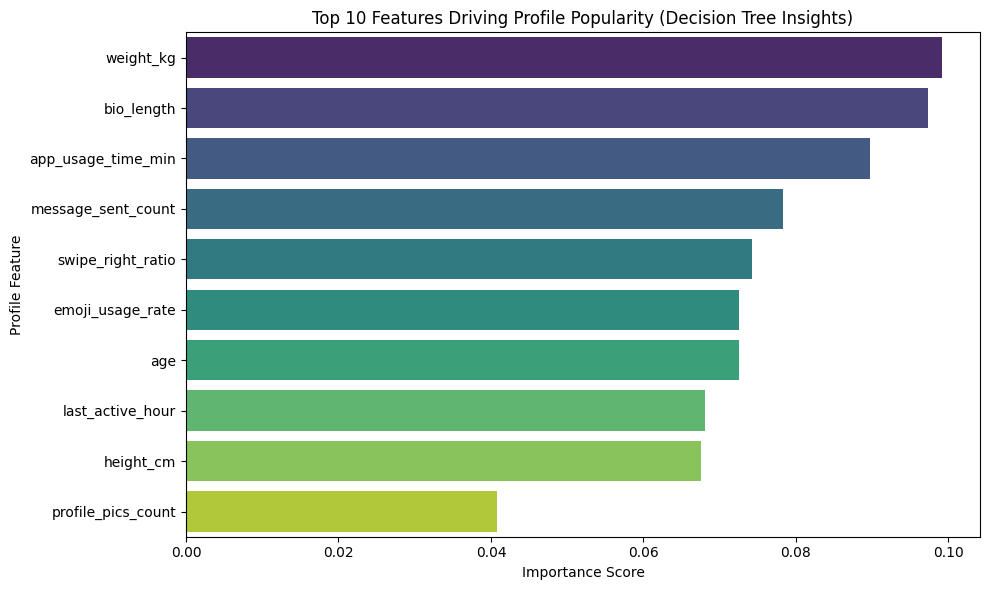


Top 3 Driving Factors for Popularity:
- weight_kg (Score: 0.0992)
- bio_length (Score: 0.0973)
- app_usage_time_min (Score: 0.0898)


In [15]:
# Extract feature importances from the TUNED Decision Tree (best_dt)
importances = best_dt.feature_importances_

# Create a DataFrame to hold the feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort them from most important to least
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the Top 10 most important features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Features Driving Profile Popularity (Decision Tree Insights)")
plt.xlabel("Importance Score")
plt.ylabel("Profile Feature")
plt.tight_layout()
plt.show()

print("\nTop 3 Driving Factors for Popularity:")
for i, row in feature_importance_df.head(3).iterrows():
    print(f"- {row['Feature']} (Score: {row['Importance']:.4f})")

In [16]:
import joblib

# Export the trained Decision Tree model to a file
joblib.dump(best_dt, 'dating_model.pkl')

print("Model successfully saved as 'dating_model.pkl'!")

Model successfully saved as 'dating_model.pkl'!
